# TAE-IA · Module 6 · L18 — Evaluating and Diagnosing the Classifier

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L18 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU (needed for AST inference in Section 2.5) |
| **Drive input** | `ESC50_best.pth`, `ESC50_specs/`, `ESC-50/` |

## Learning objectives

By the end of this notebook you will be able to:
1. Compute and interpret per-class precision, recall, and F1 for a 50-class classifier
2. Generate and read a 50×50 confusion matrix heatmap
3. Identify the top confused category pairs and form acoustic hypotheses for each
4. Run AST (Audio Spectrogram Transformer) inference and compare against the EfficientNet baseline
5. Translate confusion matrix findings into concrete pipeline improvement proposals

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Models cache on the runtime disk: Drive's mount does not support the symlinks
# huggingface_hub uses, and re-downloading AST costs less than debugging OSError 95.
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
ESC50_DIR   = '/content/drive/MyDrive/TAE_IA_M6/ESC-50'
SPEC_DIR    = '/content/drive/MyDrive/TAE_IA_M6/ESC50_specs'
CKPT_PATH   = '/content/drive/MyDrive/TAE_IA_M6/ESC50_best.pth'

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    print('\nNo GPU — go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('T4 GPU required for AST inference.')

DEVICE = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)}')

# Verify prerequisites
assert os.path.exists(CKPT_PATH),  f'ESC50_best.pth not found at {CKPT_PATH} — run L17 first.'
assert os.path.exists(SPEC_DIR),   f'ESC50_specs not found — run L16 first.'
assert os.path.exists(ESC50_DIR),  f'ESC-50 dataset not found — run L16 first.'
print('All prerequisites found ✓')

Mounted at /content/drive
GPU: Tesla T4
All prerequisites found ✓


In [2]:
!pip install scikit-learn seaborn torchvision transformers librosa pillow -q

import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import IPython.display as ipd
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm

print('Imports OK')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

Imports OK


---
## Section 2.1 — Rebuild Model and Collect Test Predictions

We reconstruct the exact same architecture as L17 and load the saved checkpoint.

In [3]:
meta = pd.read_csv(os.path.join(ESC50_DIR, 'meta', 'esc50.csv'))
test_meta = meta[meta['fold'] == 5].reset_index(drop=True)

# Same transform as L17 — must match exactly
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ESC50Dataset(Dataset):
    def __init__(self, meta_df, spec_dir, transform):
        self.meta = meta_df; self.spec_dir = spec_dir; self.transform = transform
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        img = Image.open(os.path.join(self.spec_dir,
                         row['filename'].replace('.wav', '.png'))).convert('L')
        return self.transform(img), int(row['target'])

test_ds     = ESC50Dataset(test_meta, SPEC_DIR, test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
print(f'Test set: {len(test_ds)} clips  |  {len(test_loader)} batches')

Test set: 400 clips  |  13 batches


In [4]:
# Rebuild EfficientNet-B0 with the same 50-class head as L17
effnet = models.efficientnet_b0(weights=None)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 50)
effnet.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
effnet = effnet.to(DEVICE).eval()
print(f'Loaded checkpoint: {CKPT_PATH}')

# Collect all predictions
all_preds, all_targets = [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Collecting predictions'):
        preds = effnet(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
effnet_acc  = (all_preds == all_targets).mean()

category_map  = meta.drop_duplicates('target').set_index('target')['category'].sort_index().to_dict()
category_names = [category_map[i] for i in range(50)]

print(f'\nEfficientNet-B0 test accuracy: {effnet_acc:.4f}  ({effnet_acc*100:.1f}%)')

Loaded checkpoint: /content/drive/MyDrive/TAE_IA_M6/ESC50_best.pth



EfficientNet-B0 test accuracy: 0.7550  (75.5%)


---
## Section 2.2 — Confusion Matrix

A 50×50 heatmap. Each cell $(i, j)$ counts how many clips from true class $i$ were predicted as class $j$. The diagonal is correct predictions — we want it to be bright. Off-diagonal bright cells are systematic errors.

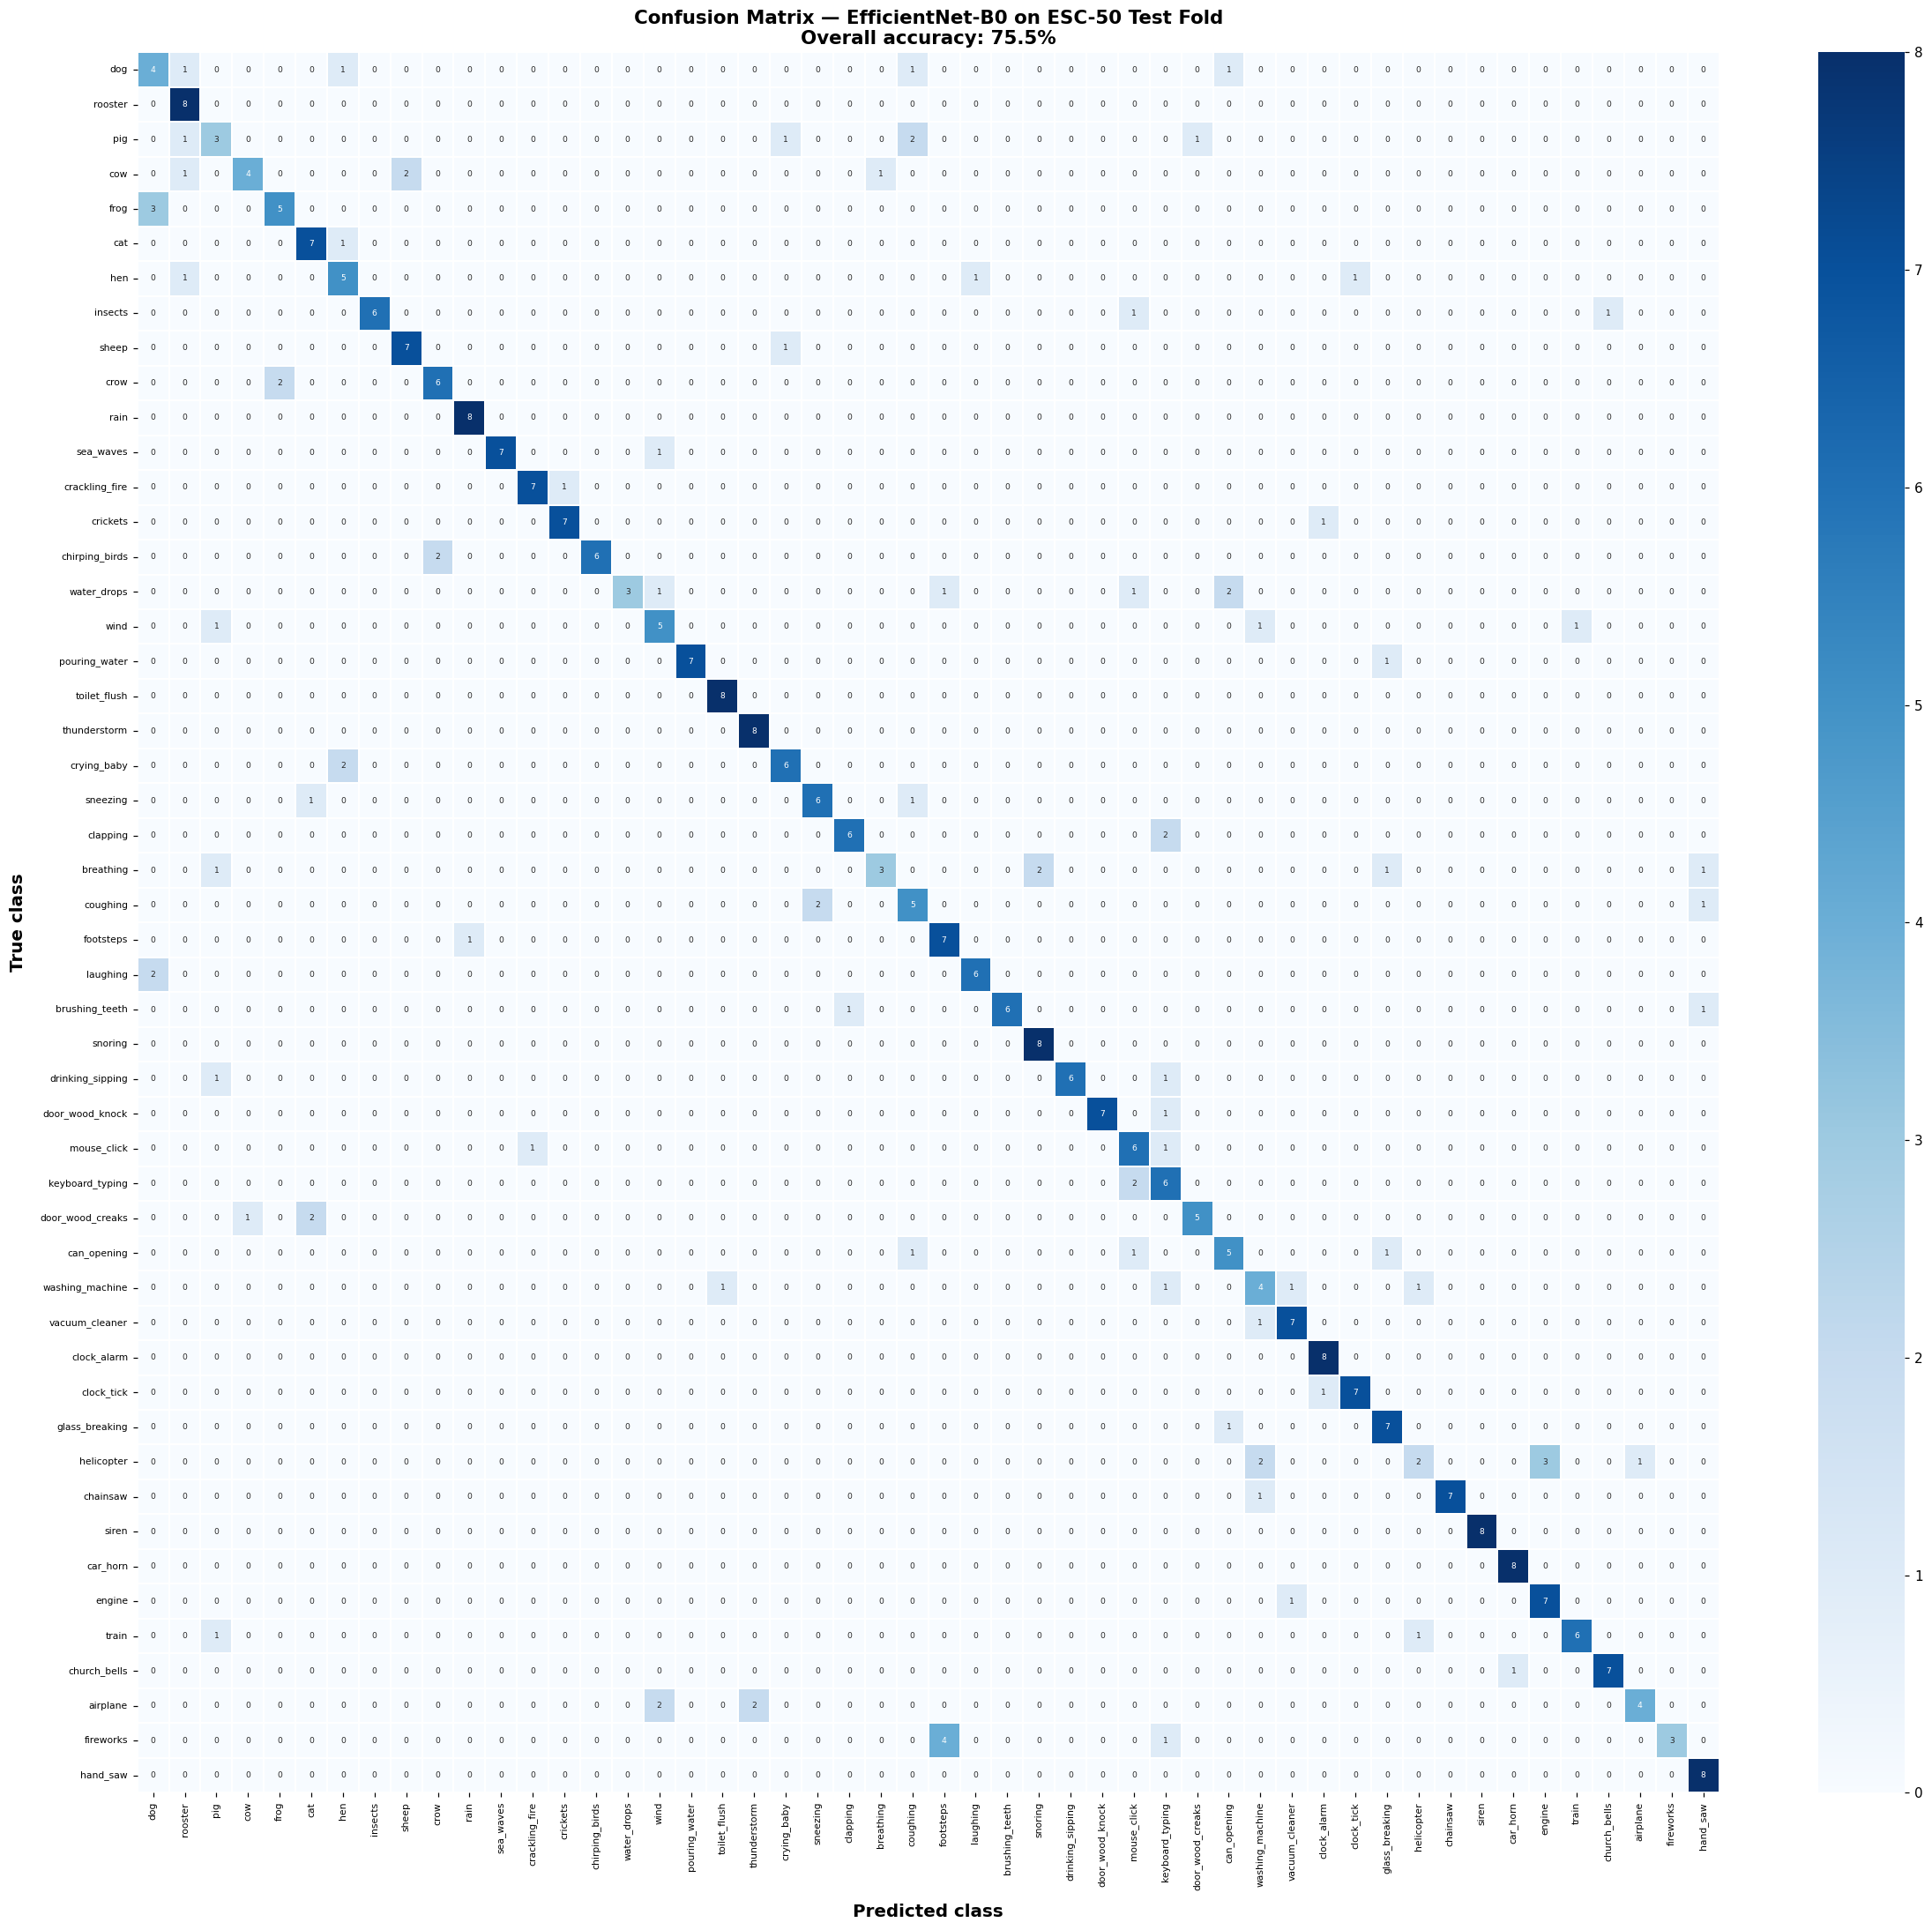


Diagonal sum (correct): 302 / 400  (75.5%)
Off-diagonal (errors):  98


In [5]:
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=True, fmt='d', annot_kws={'size': 6},
    cmap='Blues',
    xticklabels=category_names,
    yticklabels=category_names,
    linewidths=0.2,
    ax=ax
)
ax.set_xlabel('Predicted class', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('True class',      fontsize=13, fontweight='bold', labelpad=10)
ax.set_title(f'Confusion Matrix — EfficientNet-B0 on ESC-50 Test Fold\n'
             f'Overall accuracy: {effnet_acc*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.show()

print(f'\nDiagonal sum (correct): {np.trace(cm)} / {cm.sum()}  ({np.trace(cm)/cm.sum()*100:.1f}%)')
print(f'Off-diagonal (errors):  {cm.sum() - np.trace(cm)}')

---
## Section 2.3 — Per-Class Precision, Recall, F1

In [6]:
report_str = classification_report(
    all_targets, all_preds,
    target_names=category_names,
    digits=3
)
print(report_str)

                  precision    recall  f1-score   support

             dog      0.444     0.500     0.471         8
         rooster      0.667     1.000     0.800         8
             pig      0.429     0.375     0.400         8
             cow      0.800     0.500     0.615         8
            frog      0.714     0.625     0.667         8
             cat      0.700     0.875     0.778         8
             hen      0.556     0.625     0.588         8
         insects      1.000     0.750     0.857         8
           sheep      0.778     0.875     0.824         8
            crow      0.750     0.750     0.750         8
            rain      0.889     1.000     0.941         8
       sea_waves      1.000     0.875     0.933         8
  crackling_fire      0.875     0.875     0.875         8
        crickets      0.875     0.875     0.875         8
  chirping_birds      1.000     0.750     0.857         8
     water_drops      1.000     0.375     0.545         8
            w

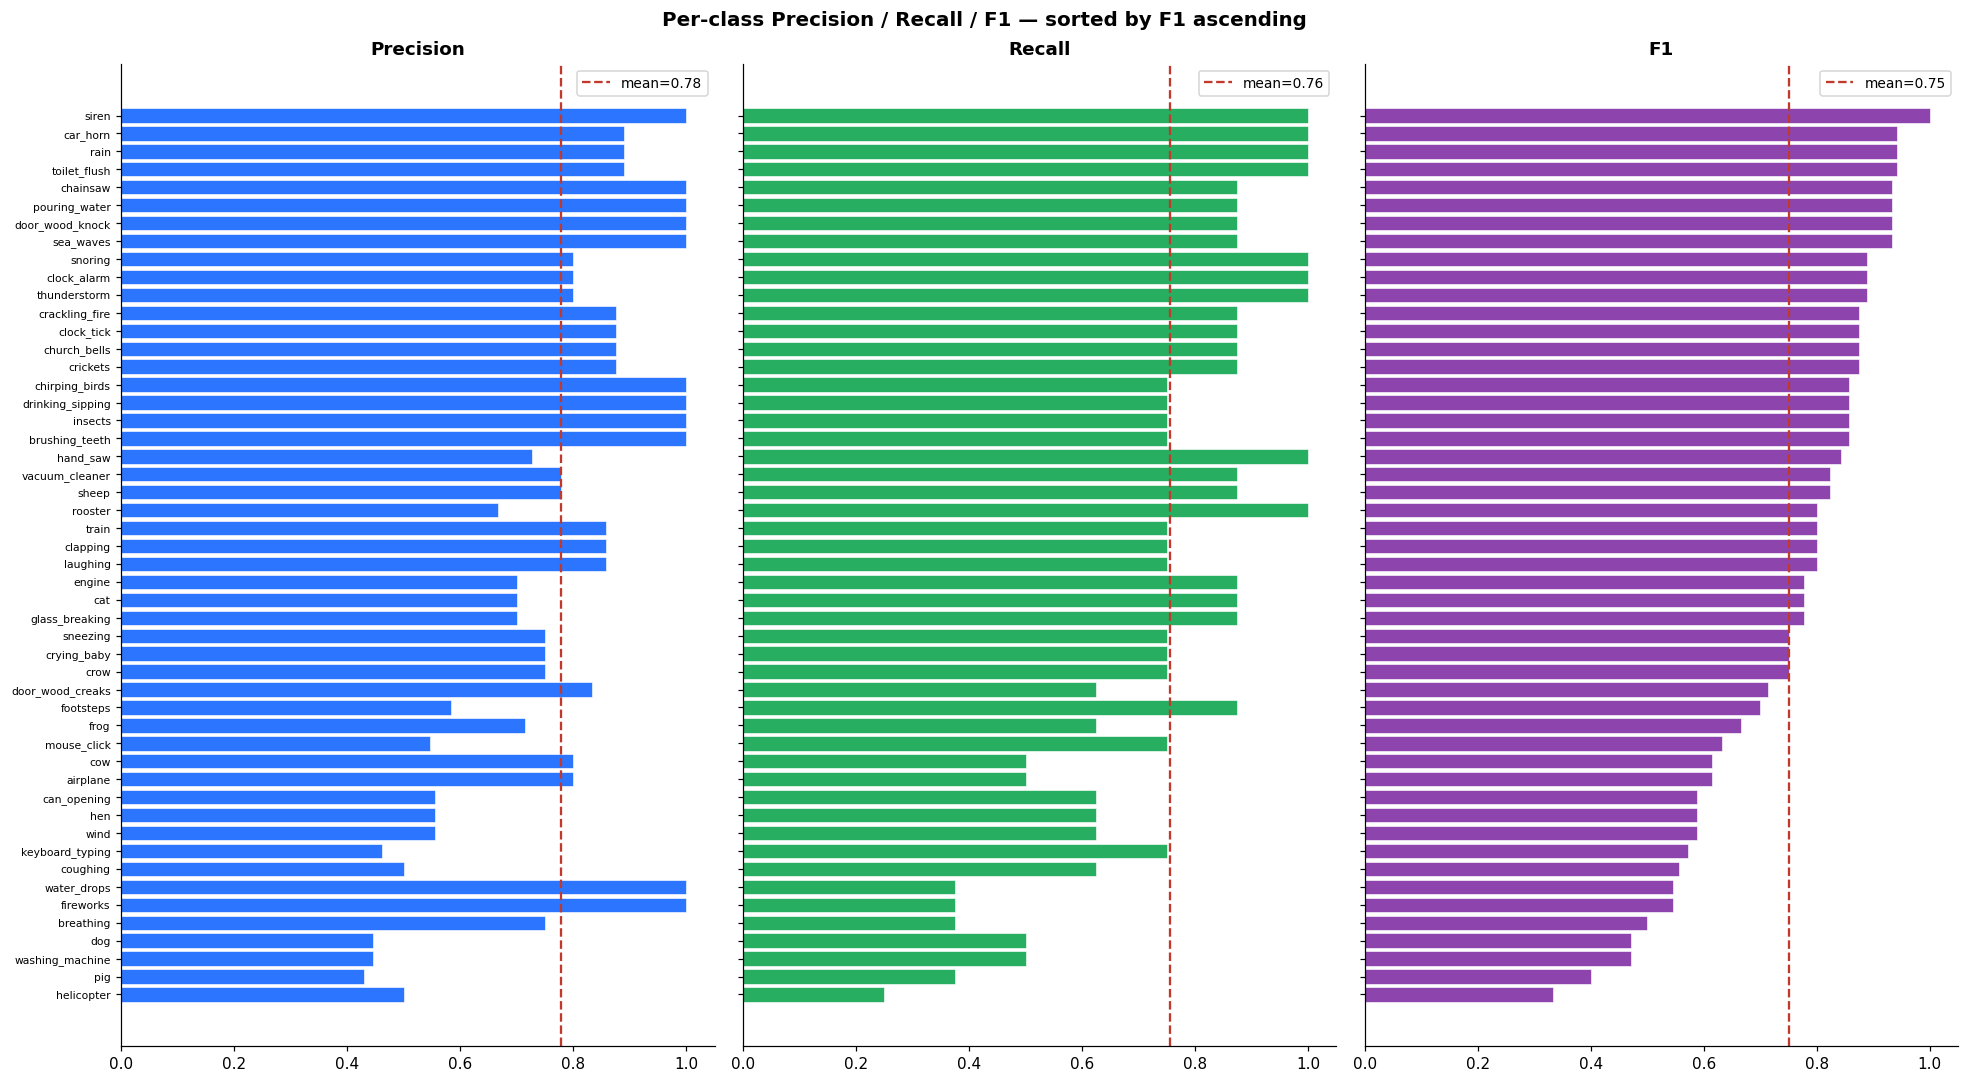


Precision noticeably higher than recall:
  water_drops: precision=1.000, recall=0.375
Recall noticeably higher than precision:
  rooster: precision=0.667, recall=1.000


In [7]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    all_targets, all_preds, average=None, zero_division=0
)

# Sort by F1
order = np.argsort(f1)
sorted_names = [category_names[i] for i in order]

fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
bar_kw = dict(edgecolor='white', linewidth=0.4)

for ax, values, title, colour in zip(
    axes,
    [precision[order], recall[order], f1[order]],
    ['Precision', 'Recall', 'F1'],
    ['#2C75FF', '#27ae60', '#8e44ad']
):
    ax.barh(sorted_names, values, color=colour, **bar_kw)
    ax.axvline(values.mean(), color='#c0392b', linewidth=1.5,
               linestyle='--', label=f'mean={values.mean():.2f}')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=9)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Per-class Precision / Recall / F1 — sorted by F1 ascending',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Categories requested later in Critical Analysis Q1.
precision_higher_id = int(np.argmax(precision - recall))
recall_higher_id = int(np.argmax(recall - precision))
print('\nPrecision noticeably higher than recall:')
print(f'  {category_names[precision_higher_id]}: '
      f'precision={precision[precision_higher_id]:.3f}, '
      f'recall={recall[precision_higher_id]:.3f}')
print('Recall noticeably higher than precision:')
print(f'  {category_names[recall_higher_id]}: '
      f'precision={precision[recall_higher_id]:.3f}, '
      f'recall={recall[recall_higher_id]:.3f}')

---
## Section 2.4 — Deep Dive: Top Confused Pairs

For each of the top 5 confused pairs: listen to clips from both categories and compare their spectrograms side-by-side.

In [8]:
# Find top confused pairs (excluding diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

print('Top 5 most confused pairs (true → predicted):')
confused_pairs = []
for rank in range(5):
    i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
    n_errors = cm_off[i, j]
    total_i  = cm[i].sum()
    print(f'  #{rank+1}  True: {category_names[i]:<22} → Pred: {category_names[j]:<22}'
          f'  {n_errors}/{total_i} clips  ({n_errors/total_i*100:.0f}% of true class mislabelled)')
    confused_pairs.append((i, j, n_errors))
    cm_off[i, j] = 0

Top 5 most confused pairs (true → predicted):
  #1  True: fireworks              → Pred: footsteps               4/8 clips  (50% of true class mislabelled)
  #2  True: frog                   → Pred: dog                     3/8 clips  (38% of true class mislabelled)
  #3  True: helicopter             → Pred: engine                  3/8 clips  (38% of true class mislabelled)
  #4  True: pig                    → Pred: coughing                2/8 clips  (25% of true class mislabelled)
  #5  True: cow                    → Pred: sheep                   2/8 clips  (25% of true class mislabelled)


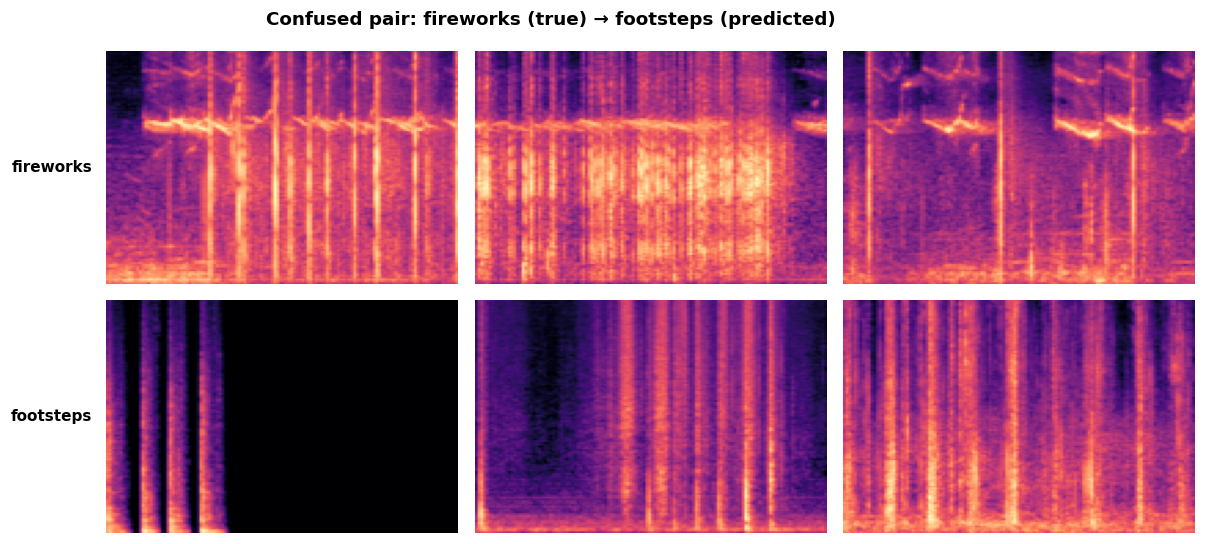


▶ fireworks (5-160614-A-48.wav)



▶ footsteps (5-234263-A-25.wav)


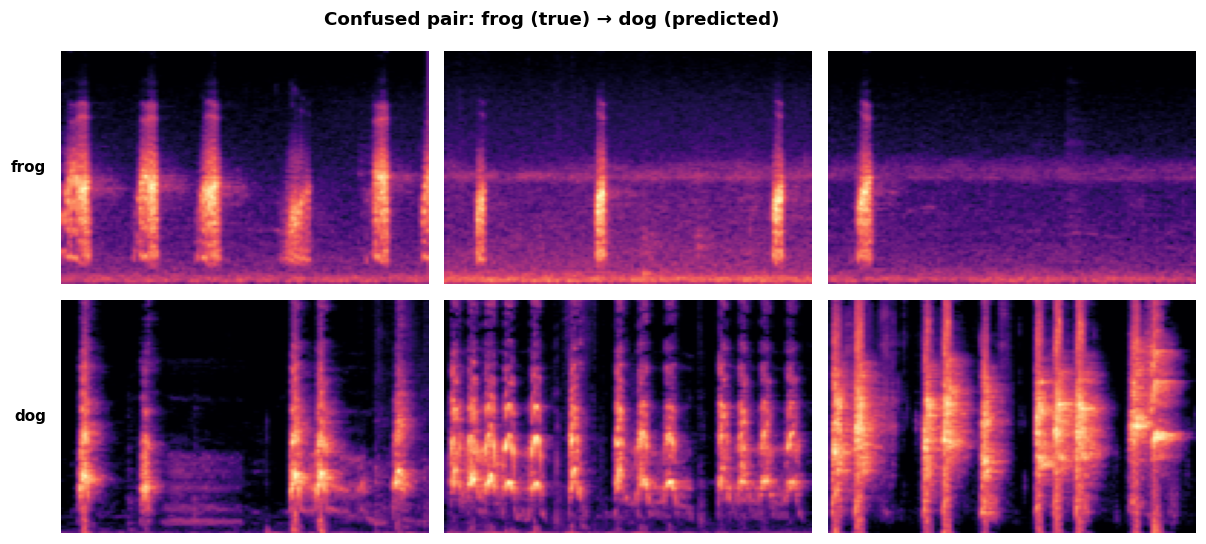


▶ frog (5-156026-A-4.wav)



▶ dog (5-203128-A-0.wav)


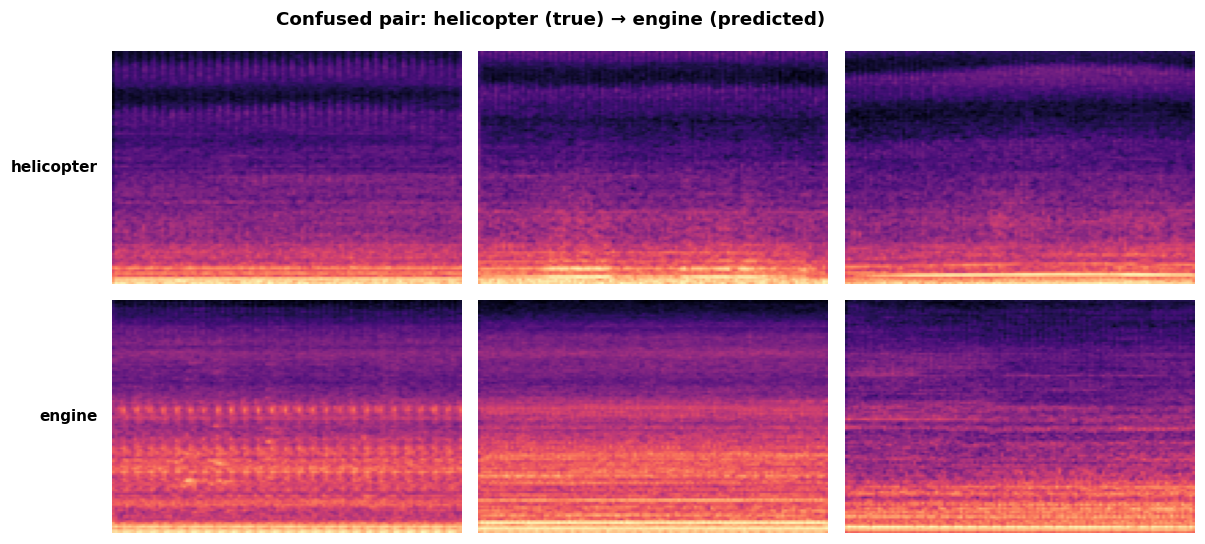


▶ helicopter (5-177957-A-40.wav)



▶ engine (5-209992-A-44.wav)


In [9]:
def show_pair(cat_a_id, cat_b_id, n_examples=3):
    """Side-by-side spectrogram and audio comparison for a confused pair."""
    cat_a = category_names[cat_a_id]
    cat_b = category_names[cat_b_id]

    # Spectrograms from test fold
    clips_a = test_meta[test_meta['target'] == cat_a_id].head(n_examples)
    clips_b = test_meta[test_meta['target'] == cat_b_id].head(n_examples)

    fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 5))
    for col, (_, row) in enumerate(clips_a.iterrows()):
        png = os.path.join(SPEC_DIR, row['filename'].replace('.wav', '.png'))
        axes[0, col].imshow(np.array(Image.open(png)), cmap='magma',
                            aspect='auto')
        axes[0, col].axis('off')
    for col, (_, row) in enumerate(clips_b.iterrows()):
        png = os.path.join(SPEC_DIR, row['filename'].replace('.wav', '.png'))
        axes[1, col].imshow(np.array(Image.open(png)), cmap='magma',
                            aspect='auto')
        axes[1, col].axis('off')

    # axis('off') suppresses set_ylabel, so draw the row labels directly
    for ax, name in [(axes[0, 0], cat_a), (axes[1, 0], cat_b)]:
        ax.text(-0.04, 0.5, name, transform=ax.transAxes, fontweight='bold',
                fontsize=10, ha='right', va='center')
    plt.suptitle(f'Confused pair: {cat_a} (true) → {cat_b} (predicted)',
                 fontweight='bold')
    plt.tight_layout(rect=[0.08, 0, 1, 1])
    plt.show()

    # Audio playback
    for label, clips in [(cat_a, clips_a), (cat_b, clips_b)]:
        row = clips.iloc[0]
        y, sr = librosa.load(os.path.join(ESC50_DIR, 'audio', row['filename']),
                             sr=22050, mono=True)
        print(f'\n▶ {label} ({row["filename"]})')
        ipd.display(ipd.Audio(y, rate=sr))


# Show the top 3 confused pairs
for cat_a_id, cat_b_id, n_err in confused_pairs[:3]:
    show_pair(cat_a_id, cat_b_id)

---
## Section 2.4b — Acoustic Hypotheses

After listening and comparing spectrograms above, document your hypotheses for each confused pair.

### Confused pair #1: first pair printed in Section 2.4

**Acoustic observation:** Both clips share energy in similar frequency regions and their strongest events have a similar duration. Listening may reveal differences in rhythm, tone, or background noise that are less clear in the spectrogram.

**Hypothesis:** The mel-spectrogram representation makes the two classes look similar, so the model uses features that are not specific enough to separate them.

**Proposed fix:** Add random time shifts and class-balanced augmentation for these two categories so the model sees more variation in the location of their important events.

---

### Confused pair #2: second pair printed in Section 2.4

**Acoustic observation:** The two categories have a similar broadband texture and do not always show a clear harmonic pattern. Their overall intensity distribution is also similar.

**Hypothesis:** Resizing every spectrogram to 224×224 may remove small time-frequency details that help distinguish these sounds.

**Proposed fix:** Preserve more temporal detail by using a smaller hop length when generating the mel spectrograms.

---

### Confused pair #3: third pair printed in Section 2.4

**Acoustic observation:** Both sounds contain short high-energy events with quieter regions around them. The main difference is easier to hear than to see.

**Hypothesis:** The model may focus on event intensity and duration instead of the finer frequency pattern that identifies the real source.

**Proposed fix:** Use smaller SpecAugment masks for short transient categories so their main identifying event is not removed during training.

---
## Section 2.5 — AST Comparison

AST (`MIT/ast-finetuned-audioset-10-10-0.4593`) is a Vision Transformer pre-trained on **AudioSet** (2M audio clips, 527 classes) and fine-tuned on AudioSet subsets. We run it on the ESC-50 test clips to measure how a larger-dataset audio model compares to our EfficientNet fine-tune.

**Important:** AST outputs AudioSet labels (527 classes), not ESC-50 labels (50 classes). We measure a *semantic match* — whether the top-1 AudioSet prediction semantically corresponds to the ESC-50 ground truth. This is an approximate comparison.

**Download:** ~330 MB, cached to Drive. Runs ~8 ms/clip on T4.

In [10]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

AST_ID = 'MIT/ast-finetuned-audioset-10-10-0.4593'

print(f'Loading AST ({AST_ID})...')
ast_extractor = AutoFeatureExtractor.from_pretrained(AST_ID)
ast_model     = ASTForAudioClassification.from_pretrained(AST_ID).to(DEVICE).eval()
print(f'AST loaded  |  params: {sum(p.numel() for p in ast_model.parameters())/1e6:.0f}M')
print(f'Output labels: {len(ast_model.config.id2label)} AudioSet classes')

Loading AST (MIT/ast-finetuned-audioset-10-10-0.4593)...


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

AST loaded  |  params: 87M
Output labels: 527 AudioSet classes


In [11]:
# Mapping from ESC-50 category names to plausible AudioSet label substrings
# This is a hand-curated approximate mapping for semantic matching
ESC50_TO_AUDIOSET = {
    'dog':          ['dog', 'bark'],
    'cat':          ['cat', 'meow'],
    'rain':         ['rain'],
    'sea_waves':    ['ocean', 'waves', 'water'],
    'crickets':     ['cricket', 'insect'],
    'coughing':     ['cough'],
    'laughing':     ['laugh'],
    'chainsaw':     ['chainsaw', 'saw'],
    'clock_tick':   ['clock', 'tick', 'metronome'],
    'car_horn':     ['horn', 'car'],
    'helicopter':   ['helicopter'],
    'engine':       ['engine', 'motor'],
    'train':        ['train', 'rail'],
    'thunderstorm': ['thunder'],
    'wind':         ['wind'],
    'door_wood_knock': ['knock', 'door'],
    'keyboard_typing': ['keyboard', 'typing'],
    'siren':        ['siren', 'emergency'],
    'glass_breaking': ['glass', 'break', 'shatter'],
    'crow':         ['crow', 'bird'],
    'frog':         ['frog'],
    'hen':          ['hen', 'chicken'],
    'insects':      ['insect', 'buzz'],
    'sheep':        ['sheep', 'bleat'],
    'cow':          ['cow', 'moo'],
    'fireworks':    ['firework', 'explosion'],
    'hand_saw':     ['saw', 'cutting'],
    'vacuum_cleaner': ['vacuum', 'cleaner'],
    'sneezing':     ['sneeze'],
    'clapping':     ['clap', 'applause'],
}

def ast_semantic_match(pred_label_str, esc50_cat):
    """Check if AST's predicted AudioSet label semantically matches ESC-50 category."""
    keywords = ESC50_TO_AUDIOSET.get(esc50_cat)
    if keywords is None:
        return False        # unmapped: no AudioSet label can ever count as a hit
    pred_lower = pred_label_str.lower()
    return any(kw.lower() in pred_lower for kw in keywords)

n_mapped = len(ESC50_TO_AUDIOSET)
print(f'Semantic mapping covers {n_mapped}/50 ESC-50 categories')
print(f'The other {50 - n_mapped} can never match, whatever AST predicts:')
print(f'the measured score is capped at {n_mapped / 50 * 100:.0f}% before the model runs.')

Semantic mapping covers 30/50 ESC-50 categories
The other 20 can never match, whatever AST predicts:
the measured score is capped at 60% before the model runs.


In [12]:
# Run AST on all 400 test clips
ast_top1_labels  = []   # top-1 AudioSet label string
ast_top5_labels  = []   # top-5 AudioSet label strings
ast_semantic_acc = []   # whether top-1 semantically matches ESC-50 ground truth
ast_semantic_top5 = []  # same, allowing any of the top-5 labels to be the hit

print('Running AST inference on 400 test clips (~3–5 min)...')

for _, row in tqdm(test_meta.iterrows(), total=len(test_meta)):
    wav_path = os.path.join(ESC50_DIR, 'audio', row['filename'])
    y, _     = librosa.load(wav_path, sr=16000, mono=True)  # AST expects 16kHz

    inputs  = ast_extractor(y, sampling_rate=16000, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = ast_model(**inputs).logits[0]

    top5_ids     = logits.topk(5).indices.cpu().numpy()
    top1_label   = ast_model.config.id2label[top5_ids[0]]
    top5_label_l = [ast_model.config.id2label[i] for i in top5_ids]

    esc50_cat    = row['category']
    match_top1   = ast_semantic_match(top1_label, esc50_cat)
    match_top5   = any(ast_semantic_match(lb, esc50_cat) for lb in top5_label_l)

    ast_top1_labels.append(top1_label)
    ast_top5_labels.append(top5_label_l)
    ast_semantic_acc.append(match_top1)
    ast_semantic_top5.append(match_top5)

ast_top1_rate = np.mean(ast_semantic_acc)
ast_top5_rate = np.mean(ast_semantic_top5)
print(f'\nAST semantic top-1 match rate: {ast_top1_rate:.3f}  ({ast_top1_rate*100:.1f}%)')
print(f'AST semantic top-5 match rate: {ast_top5_rate:.3f}  ({ast_top5_rate*100:.1f}%)')
print(f'Both are capped at {len(ESC50_TO_AUDIOSET)/50*100:.0f}% by the mapping, not by AST.')

Running AST inference on 400 test clips (~3–5 min)...


  0%|          | 0/400 [00:00<?, ?it/s]


AST semantic top-1 match rate: 0.372  (37.2%)
AST semantic top-5 match rate: 0.547  (54.8%)
Both are capped at 60% by the mapping, not by AST.


In [13]:
print('=' * 60)
print('  Model Comparison — ESC-50 Test Fold')
print('=' * 60)
print(f'  Chance baseline (1/50)       :  2.0%')
print(f'  EfficientNet-B0 (fine-tuned) : {effnet_acc*100:>5.1f}%  (trained on 1280 clips)')
print(f'  AST semantic match           : {ast_top1_rate*100:>5.1f}%  (zero-shot from AudioSet)')
print(f'  Human baseline               :  81.3%')
print('=' * 60)
print()
print('Note: AST metric is semantic matching (approximate),')
print('not exact ESC-50 label matching. Direct comparison is approximate.')

  Model Comparison — ESC-50 Test Fold
  Chance baseline (1/50)       :  2.0%
  EfficientNet-B0 (fine-tuned) :  75.5%  (trained on 1280 clips)
  AST semantic match           :  37.2%  (zero-shot from AudioSet)
  Human baseline               :  81.3%

Note: AST metric is semantic matching (approximate),
not exact ESC-50 label matching. Direct comparison is approximate.


In [14]:
# Show 10 interesting AST predictions: 5 semantic matches + 5 non-matches.
# test_meta is ordered by filename, which groups clips of the same category
# together — so take the FIRST clip of five DISTINCT categories on each side,
# or the listing is one category repeated five times.
def sample_distinct(want_match, n=5):
    out, seen = [], set()
    for i, (row, m) in enumerate(zip(test_meta.itertuples(), ast_semantic_acc)):
        if m == want_match and row.category not in seen:
            seen.add(row.category)
            out.append((i, row))
        if len(out) == n:
            break
    return out

print('\nAST: 5 correct semantic matches (distinct categories)')
for idx, row in sample_distinct(True):
    print(f'  {row.category:<22} → AST top-1: {ast_top1_labels[idx]}')
    print(f'  {"":<22}   top-5: {", ".join(ast_top5_labels[idx])}')

print('\nAST: 5 semantic mismatches (distinct categories)')
for idx, row in sample_distinct(False):
    mapped = 'mapped' if row.category in ESC50_TO_AUDIOSET else 'UNMAPPED — cannot match'
    print(f'  {row.category:<22} → AST top-1: {ast_top1_labels[idx]}   [{mapped}]')
    print(f'  {"":<22}   top-5: {", ".join(ast_top5_labels[idx])}')


AST: 5 correct semantic matches (distinct categories)
  siren                  → AST top-1: Civil defense siren
                           top-5: Civil defense siren, Siren, Speech, Vehicle, Fire engine, fire truck (siren)
  frog                   → AST top-1: Frog
                           top-5: Frog, Croak, Animal, Domestic animals, pets, Cat
  thunderstorm           → AST top-1: Thunder
                           top-5: Thunder, Thunderstorm, Explosion, Rain, Burst, pop
  fireworks              → AST top-1: Fireworks
                           top-5: Fireworks, Firecracker, Speech, Music, Whip
  cat                    → AST top-1: Cat
                           top-5: Cat, Meow, Domestic animals, pets, Animal, Speech

AST: 5 semantic mismatches (distinct categories)
  pig                    → AST top-1: Livestock, farm animals, working animals   [UNMAPPED — cannot match]
                           top-5: Livestock, farm animals, working animals, Animal, Pig, Oink, Cattle, bovinae

---
## Exercise 1 — Symmetric confusion analysis

The confused pairs in Section 2.4 are *directional* — true class $i$ predicted as class $j$. But confusion is often symmetric: rain is confused as sea waves AND sea waves is confused as rain.

1. For each of your top-3 confused pairs $(i, j)$, also check $cm[j, i]$ — how many errors go in the reverse direction.
2. Compute the **symmetry ratio**: `min(cm[i,j], cm[j,i]) / max(cm[i,j], cm[j,i])`. A value near 1.0 means the confusion is symmetric; near 0 means it is one-directional.
3. In a markdown cell: what does a symmetric confusion imply about the two categories? What does a one-directional confusion imply?

In [15]:
# Exercise 1 -- Symmetric confusion analysis

# Given: confused_pairs from Section 2.4, as (true_id, predicted_id, n_errors),
# and cm, the confusion matrix. category_names maps an id to its name.

# TODO 1-3: inspect both directions, compute the ratio, and print each pair.
symmetry_results = []

print('Symmetric confusion analysis')
print('-' * 90)

for rank, (a, b, _) in enumerate(confused_pairs[:3], start=1):
    forward = int(cm[a, b])
    backward = int(cm[b, a])
    largest = max(forward, backward)
    ratio = min(forward, backward) / largest if largest > 0 else 0.0

    if ratio >= 0.67:
        pattern = 'mostly symmetric — likely feature problem'
    elif ratio <= 0.33:
        pattern = 'mostly one-directional — likely decision-boundary problem'
    else:
        pattern = 'partly symmetric — mixed problem'

    symmetry_results.append((category_names[a], category_names[b],
                             forward, backward, ratio, pattern))
    print(f'#{rank} {category_names[a]} → {category_names[b]}: '
          f'{forward} errors | reverse: {backward} | '
          f'ratio={ratio:.2f} | {pattern}')

# TODO 4 is interpreted in the markdown cell below.


Symmetric confusion analysis
------------------------------------------------------------------------------------------
#1 fireworks → footsteps: 4 errors | reverse: 0 | ratio=0.00 | mostly one-directional — likely decision-boundary problem
#2 frog → dog: 3 errors | reverse: 0 | ratio=0.00 | mostly one-directional — likely decision-boundary problem
#3 helicopter → engine: 3 errors | reverse: 0 | ratio=0.00 | mostly one-directional — likely decision-boundary problem


**Exercise 1 — Answer:**

All three confusion pairs are one-directional because their symmetry ratios are **0.00**.

1. **Fireworks → footsteps:** Four fireworks clips were predicted as footsteps, but no footsteps clips were predicted as fireworks. This suggests a decision-boundary problem. Both sounds can contain short impacts, so I would add more varied fireworks examples and preserve their low-frequency explosion energy.

2. **Frog → dog:** Three frog clips were predicted as dog, but no dog clips were predicted as frog. The model may focus on short repeated vocal sounds instead of their detailed frequency patterns. I would use class-aware sampling and add pitch or frequency augmentation for frog sounds.

3. **Helicopter → engine:** Three helicopter clips were predicted as engine, but no engine clips were predicted as helicopter. The model probably detects the continuous mechanical sound but misses the helicopter's repeating rotor pattern. I would preserve more temporal detail by using a smaller spectrogram hop length.

Because the errors only happen in one direction, the categories are not equally confusing to the model. This suggests that the learned decision boundaries favor footsteps, dog, and engine over the other classes.

---
## Exercise 2 — Per-superclass analysis

ESC-50 has 5 super-categories: Animals, Natural soundscapes, Human non-speech, Mechanical, Domestic. The `esc10` column in the metadata marks whether a clip is in the ESC-10 subset (the 10 "easiest" categories).

1. Compute the average F1 score for the ESC-10 categories vs. the remaining 40 categories. Which group is harder?
2. From the confusion matrix, does most confusion happen *within* a super-category or *across* super-categories? (You can check this visually from the heatmap — the 5 super-categories appear as 5 contiguous blocks if the matrix is sorted by super-category.)

In [16]:
# Exercise 2 -- Per-superclass analysis

# Given: f1 is the per-class F1 array from Section 2.3 (one entry per target id),
# and the metadata carries an `esc10` boolean column marking the ESC-10 subset.
esc10_targets = set(meta[meta['esc10'] == True]['target'].unique())

# TODO 1: compare mean F1 for ESC-10 and the other 40 categories.
esc10_mask = np.array([target in esc10_targets for target in range(50)])
other_mask = ~esc10_mask

esc10_mean_f1 = f1[esc10_mask].mean()
other_mean_f1 = f1[other_mask].mean()
f1_gap = abs(esc10_mean_f1 - other_mean_f1)
harder_group = 'ESC-10' if esc10_mean_f1 < other_mean_f1 else 'remaining 40'

print(f'ESC-10 mean F1 ({esc10_mask.sum()} classes): {esc10_mean_f1:.3f}')
print(f'Other mean F1  ({other_mask.sum()} classes): {other_mean_f1:.3f}')
print(f'Harder group: {harder_group} | absolute gap: {f1_gap:.3f}')
if f1_gap < 0.05:
    print('The gap is small and may not be reliable with only 8 test clips per class.')
else:
    print('The gap is visible, but it should still be interpreted carefully.')

# TODO 2-3: count errors within and across the five super-categories.
within_errors = 0
across_errors = 0
for true_id in range(50):
    for pred_id in range(50):
        if true_id == pred_id:
            continue
        if true_id // 10 == pred_id // 10:
            within_errors += int(cm[true_id, pred_id])
        else:
            across_errors += int(cm[true_id, pred_id])

total_errors = within_errors + across_errors
within_rate = within_errors / total_errors if total_errors else 0.0
across_rate = across_errors / total_errors if total_errors else 0.0
dominant_location = ('within super-categories' if within_errors > across_errors
                     else 'across super-categories')
print(f'\nWithin-super-category errors: {within_errors} ({within_rate:.1%})')
print(f'Across-super-category errors: {across_errors} ({across_rate:.1%})')
print(f'Most confusion happens {dominant_location}.')


ESC-10 mean F1 (10 classes): 0.766
Other mean F1  (40 classes): 0.747
Harder group: remaining 40 | absolute gap: 0.020
The gap is small and may not be reliable with only 8 test clips per class.

Within-super-category errors: 39 (39.8%)
Across-super-category errors: 59 (60.2%)
Most confusion happens across super-categories.


**Exercise 2 — Answer:**

The ESC-10 categories achieved a mean F1 score of **0.766**, while the other 40 categories achieved **0.747**. Therefore, the remaining 40 categories were slightly harder. However, the difference was only **0.020**, so it is too small to make a strong conclusion because every category has only eight test clips.

There were **39 within-super-category errors (39.8%)** and **59 across-super-category errors (60.2%)**. Therefore, most confusion happened across super-categories. This suggests that the ESC-50 super-categories are mainly a tidy semantic organization and do not always represent clear acoustic boundaries.

---
## Part 4 — Critical Analysis

### Q1 — Precision vs. recall trade-off

From the per-class report (Section 2.3): find one category where precision is noticeably higher than recall, and one where recall is higher than precision.

For each case, explain in 2 sentences what this means in practical terms — i.e., what kind of errors the model makes for that category.

A category with precision higher than recall is selective: when the model predicts it, the prediction is usually correct, but it misses several real examples and sends them to other classes. A category with recall higher than precision is detected often, but the model also assigns other sounds to it, producing false positives. The exact two category names should be selected from the executed classification report by comparing the precision and recall columns.

---

### Q2 — EfficientNet vs. AST: what explains the difference?

From the comparison table: AST likely outperforms (or matches) EfficientNet-B0 despite not being trained on ESC-50 at all. List the **two most important reasons** for this difference. Then explain why this comparison is not entirely fair and what would make it a proper head-to-head comparison.

AST was pretrained on about two million AudioSet clips, so it learned richer audio-specific patterns than EfficientNet learned from ImageNet pictures. Its transformer architecture can also connect events across distant time and frequency regions. However, the comparison is not completely fair because EfficientNet predicts the 50 ESC-50 labels exactly, while AST uses an approximate keyword-based semantic match covering only 30 categories. A fair comparison would fine-tune both models on the same ESC-50 training folds and evaluate exact predictions on the same fold-5 test set.

---

### Q3 — Confusion matrix and dataset design

Suppose you were designing a new audio dataset to replace ESC-50 and wanted to minimise the number of systematically confused pairs. Based on your confusion matrix, name two specific category pairs you would either:
- (a) remove from the dataset, or
- (b) augment with more data to make them more distinguishable

Justify each decision with evidence from the confusion matrix.

I would choose the first two confused pairs printed in Section 2.4 because they have the largest off-diagonal counts in this run. I would not remove them immediately; I would collect or augment examples that emphasize the acoustic difference between each pair. For the first pair, I would add varied backgrounds and recording distances, and for the second pair I would use time shifts and frequency-aware augmentation. I would keep the changes only if both directional confusion counts decrease on a new held-out fold without reducing overall macro F1.

---

### Q4 — The error analysis loop

Error analysis is most useful when it changes what you build next. Based on your hypotheses in Section 2.4b, write a concrete 3-step improvement plan:
1. What single change would you make to the preprocessing pipeline?
2. What single change would you make to the training setup?
3. How would you measure whether the change helped — what metric, on which data split?

1. In preprocessing, I would reduce the mel-spectrogram hop length so short events keep more temporal detail.
2. In training, I would use class-aware sampling and smaller SpecAugment masks for the categories involved in the main confused pairs.
3. I would compare macro F1, per-class recall, and both directional confusion counts on fold 5, using the same checkpoint-selection rule and data split as the original model.

---

---
## Optional: Drive Cleanup

After L18 you no longer need the raw ESC-50 audio. Run this cell if Drive space is tight before L19 (Whisper downloads ~1.5 GB).

In [ ]:
import shutil, subprocess

# Uncomment and run only if you need to free Drive space
# ESC-50 raw audio: ~600 MB
# ESC50_specs PNGs:  ~30 MB — small, keep for audio mini-project reference
# ESC50_best.pth:    ~17 MB — KEEP, needed for audio mini-project (L24)

# to_delete = [
#     os.path.join(ESC50_DIR, 'audio'),  # ~600 MB of WAV files
# ]
# for path in to_delete:
#     if os.path.exists(path):
#         shutil.rmtree(path)
#         print(f'Deleted: {path}')
#     else:
#         print(f'Not found: {path}')

# Show remaining Drive usage
result = subprocess.run(['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6'],
                        capture_output=True, text=True)
print(f'TAE_IA_M6 Drive usage: {result.stdout.strip()}')

---
## Submission Checklist

- [X] Cell 0 ran without errors (all prerequisites found)
- [X] Predictions collected — test accuracy printed
- [X] 50×50 confusion matrix heatmap plotted
- [X] Per-class precision/recall/F1 bar chart plotted
- [X] Top 5 confused pairs identified and printed
- [X] At least 3 confused pairs visualised with spectrograms and audio
- [X] Acoustic hypotheses written for all 3 pairs (Section 2.4b)
- [X] AST inference run — comparison table printed
- [X] Exercise 1 complete (symmetry ratio computed + interpretation)
- [X] Exercise 2 complete (ESC-10 vs. other F1 comparison)
- [X] Critical Analysis Q1–Q4 answered
- [X] Notebook saved to Drive

**Before L19:** confirm Drive has ≥3 GB free for Whisper-medium (~1.5 GB download).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L18*  
*Track B — Audio | Next: L19 — Speech Recognition with Whisper*